# 1. Preparação da base e limpeza dos dados

In [143]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
Path to dataset files: /kaggle/input/wine-quality-dataset


In [144]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, cross_val_score)
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             average_precision_score, RocCurveDisplay,
                             PrecisionRecallDisplay)
import xgboost as xgb

In [145]:
df = pd.read_csv(path + "/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [146]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [147]:
#plt.plot(df['alcohol'], df['quality'], marker='o')
#df.plot(kind='scatter', x='alcohol', y='density')
#plt.title('alcohol vs density')
#plt.xlabel('alcohol')
#plt.ylabel('density')
#plt.show()

In [148]:
df.shape

(1143, 13)

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [150]:
df.duplicated().sum()


np.int64(0)

In [151]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


# 1. Compreensão do Problema

### 1.1 Contexto do problema.

Desenvolver um modelo de classificação capaz de prever a qualidade de
um vinho com base em suas características físico-químicas.

Para simplificar o
problema, a variável de qualidade deverá ser transformada em uma classificação
binária, por exemplo:

● Vinho de Alta Qualidade: nota ≥ 7

● Vinho de Baixa/Média Qualidade: nota < 7

O objetivo é treinar e avaliar modelos de aprendizado de máquina capazes de
prever essa classificação a partir das variáveis disponíveis.

### 1.2 Definir claramente a variável alvo.

A variavel alvo será a **quality**, que utilizaremos para auxiliar no preenchimento da nova coluna (**qualityBinary**), que recebará os valores binários, sendo:

● quality ≥ 7, então qualityBinary = 1

● quality < 7, então qualityBinary = 0

In [152]:
#Criando a nova coluna binária
df['qualityBinary'] = int

### 1.3 Realizar a transformação da variável de qualidade em classificação binária.



In [153]:
# 1. Função, vai preencher o campo
def classificar_qualidade(valor):
    if valor >= 7:
        return 1
    else:
        return 0

# 2. Aplica a função na coluna 'quality' e salva na 'QualityBinary'
df['qualityBinary'] = df['quality'].apply(classificar_qualidade)

In [154]:
resultado = df.groupby('qualityBinary').head(5)

resultado

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,qualityBinary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,7,1
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,8,1
12,8.5,0.28,0.56,1.8,0.092,35.0,103.0,0.9969,3.30,0.75,10.5,7,16,1
27,8.1,0.38,0.28,2.1,0.066,13.0,30.0,0.9968,3.23,0.73,9.7,7,37,1
89,8.0,0.59,0.16,1.8,0.065,3.0,16.0,0.9962,3.42,0.92,10.5,7,128,1


# 2. Análise Exploratória de Dados (EDA)


### 2.1 Investigação da distribuição das variáveis.


In [155]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [156]:
# Mostra a quantidade de 0s e 1s
df['qualityBinary'].value_counts()

,count
qualityBinary,
0,984
1,159


In [157]:
# em porcentagem (%)
df['qualityBinary'].value_counts(normalize=True) * 100

,proportion
qualityBinary,
0,86.089239
1,13.910761


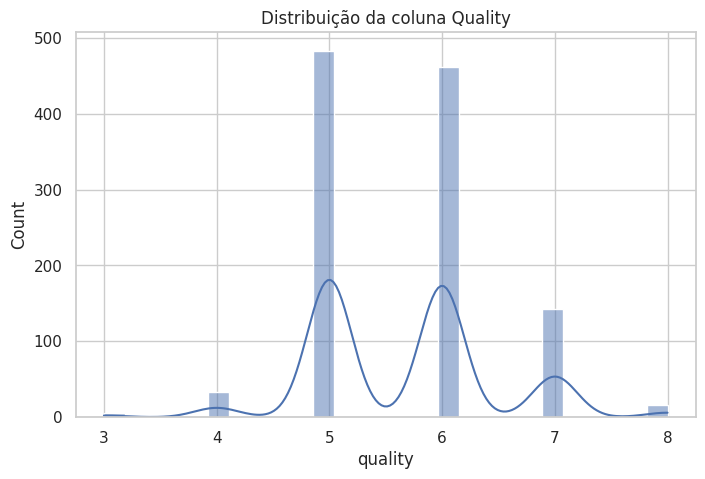

In [158]:
# Configura o estilo dos gráficos para ficarem mais bonitos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='quality', kde=True)
plt.title('Distribuição da coluna Quality')
plt.show()

### 2.2 Identificação de correlações entre as variáveis e possíveis outliers ou valores inconsistentes.

/tmp/ipykernel_860/4166714180.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='qualityBinary', palette='Set2')


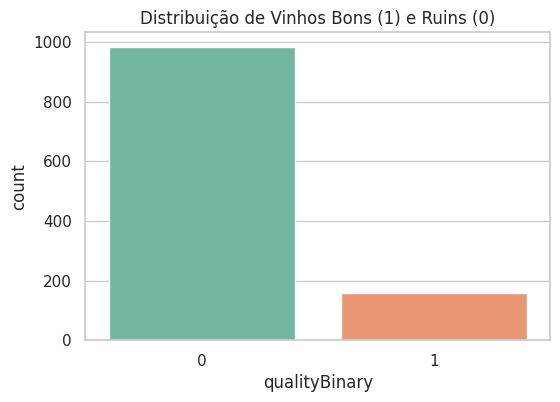

In [159]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='qualityBinary', palette='Set2')
plt.title('Distribuição de Vinhos Bons (1) e Ruins (0)')
plt.show()

/tmp/ipykernel_860/4024892635.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='qualityBinary', y='alcohol', palette=['#95a5a6', '#c0392b'], width=0.5)


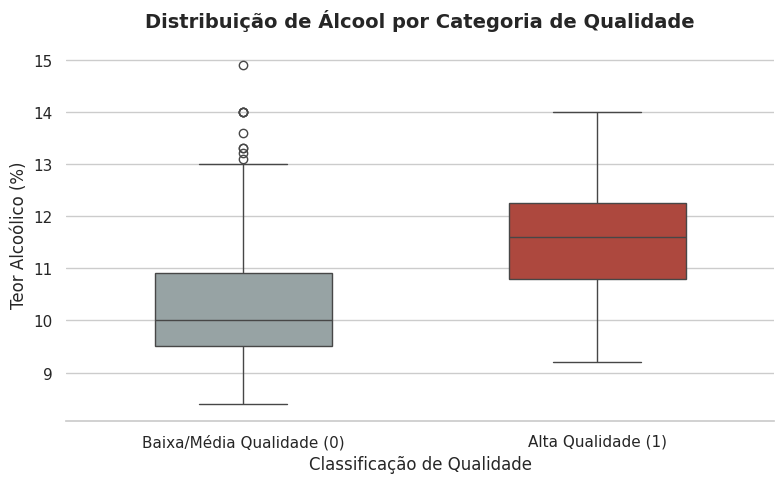

In [160]:
# Exemplo: Distribuição do álcool separado pela qualidade binária
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

sns.boxplot(data=df, x='qualityBinary', y='alcohol', palette=['#95a5a6', '#c0392b'], width=0.5)


plt.title('Distribuição de Álcool por Categoria de Qualidade', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classificação de Qualidade', fontsize=12)
plt.ylabel('Teor Alcoólico (%)', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Baixa/Média Qualidade (0)', 'Alta Qualidade (1)'])

sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Matriz de Correlação de Características'}>

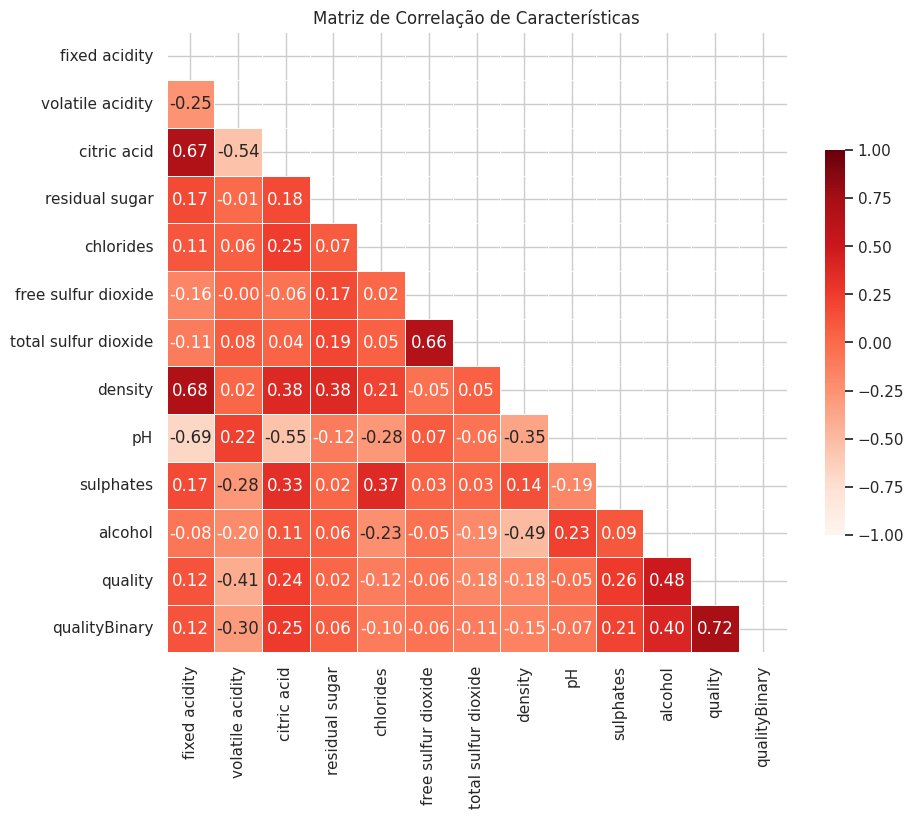

In [161]:
# Remover coluna de Id, que não é característica do vinho
df = df.drop("Id", axis=1)

corr = df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

f, ax = plt.subplots(figsize=(10, 10))
plt.title("Matriz de Correlação de Características")
sns.set_theme(style="whitegrid", palette="Reds")
sns.heatmap(corr, mask=mask, cmap="Reds", vmin=-1, vmax=1, center=0,
            square=True, annot=True, fmt=".2f", linewidths=.5, cbar_kws={"shrink": .5})

O gráfico mostra correlação positiva entre qualidade e:

- Acidez fixa: 0,12
- Ácido cítrico: 0,24
- Sulfatos: 0,26
- Álcool: 0,48

Correlação negativa entre qualidade e:

- Acidez volátil: -0,41
- Cloretos: -0,12
- Dióxido de enxofre total: -0,18
- Densidade: -0,18

Logo, é possível assumir que as seguintes características possuem maior influência na qualidade do vinho:

- Álcool
- Sulfatos
- Ácido cítrico
- Acidez volátil

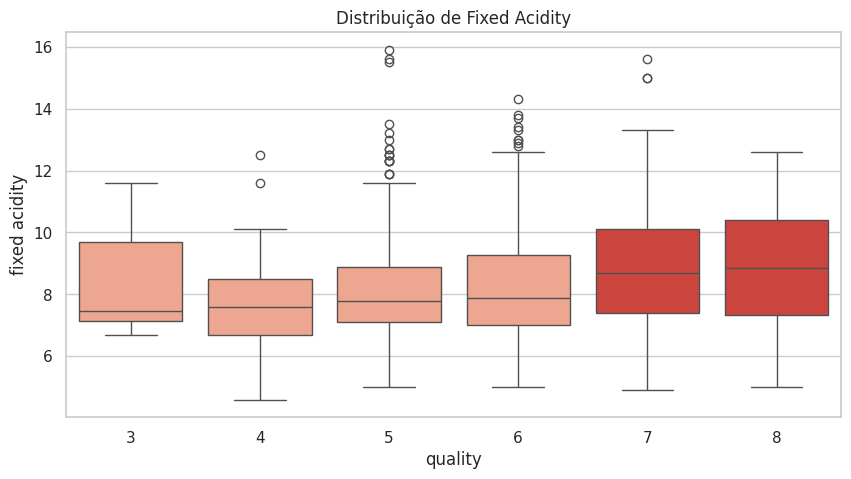

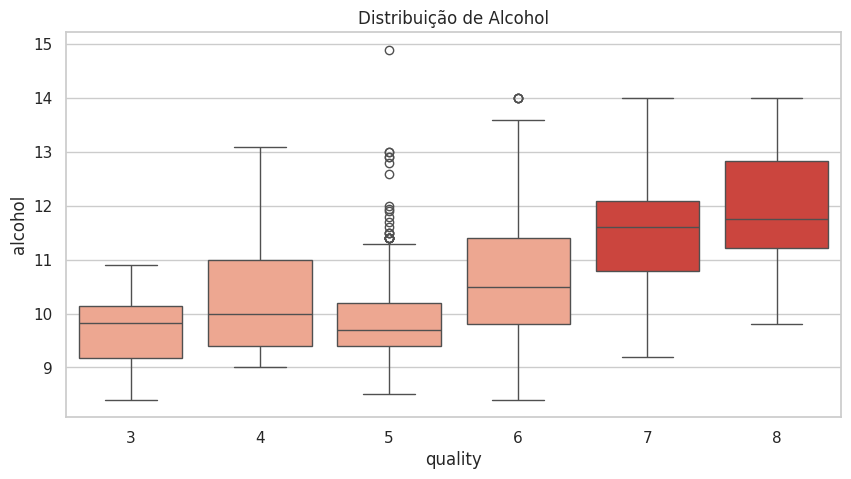

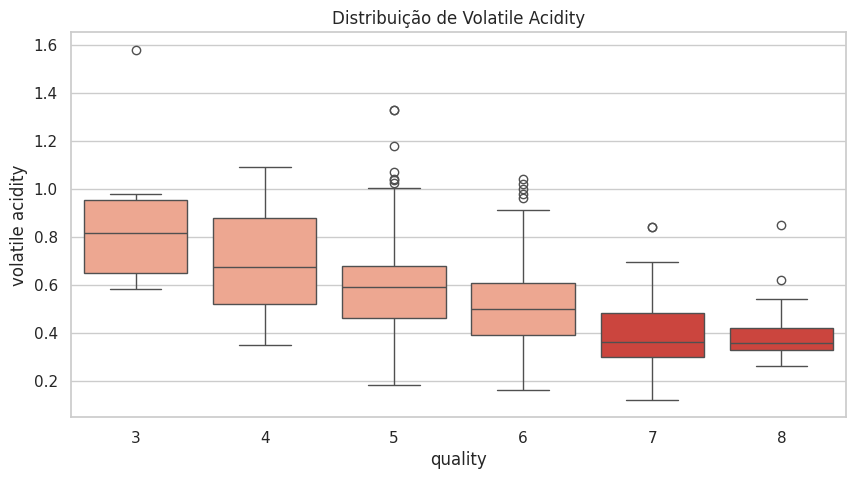

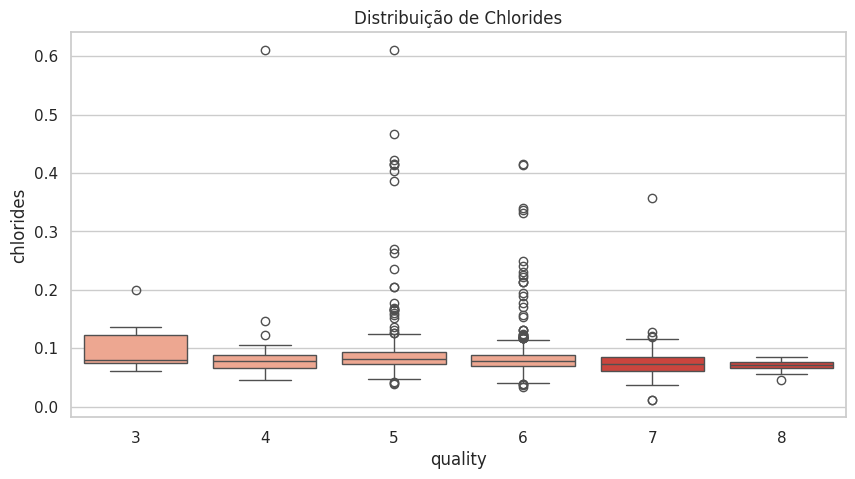

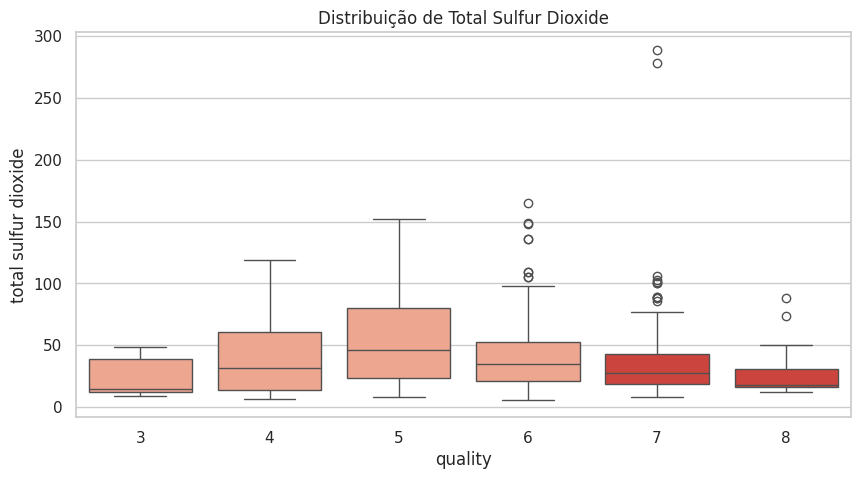

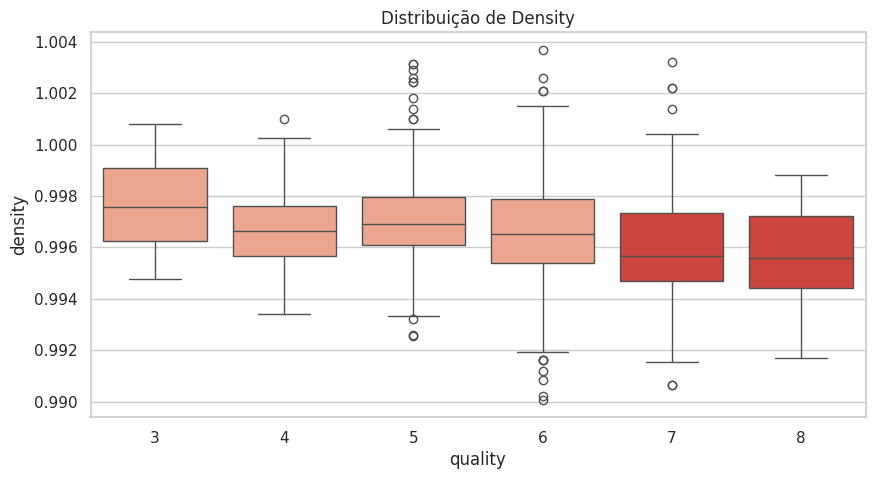

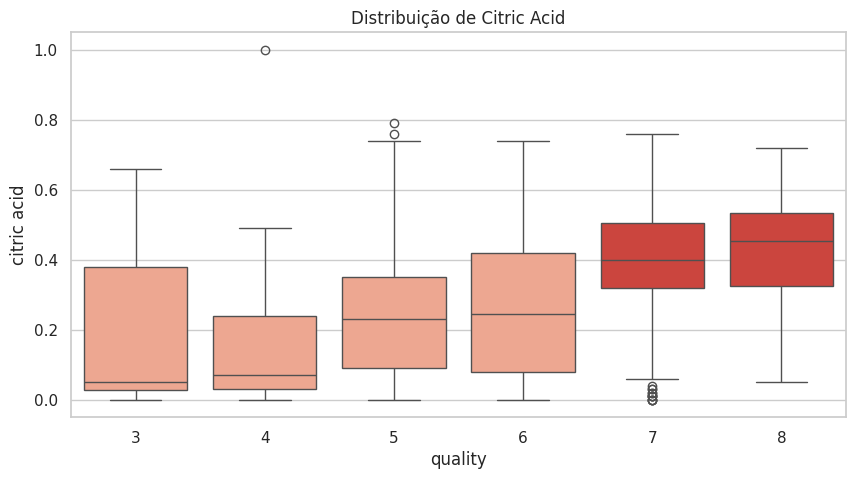

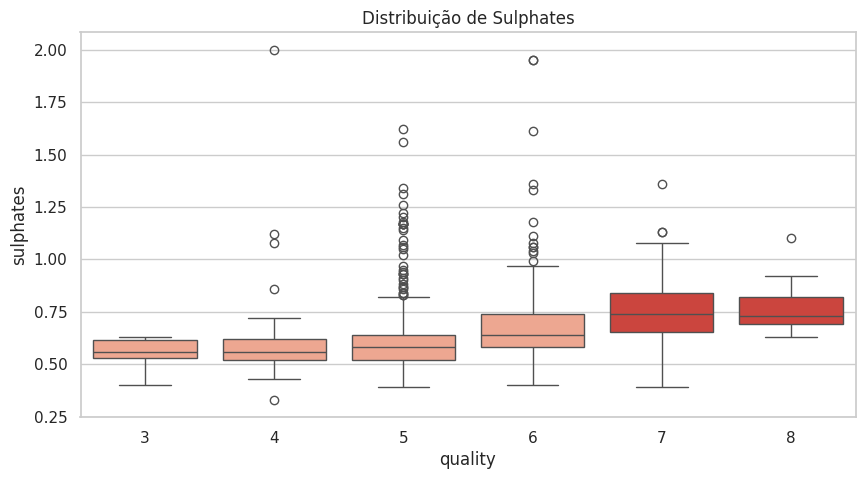

In [162]:
features = [
    'fixed acidity', 'alcohol', 'volatile acidity', 'chlorides',
    'total sulfur dioxide', 'density', 'citric acid', 'sulphates'
]

for item in features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='quality', y=item, hue='qualityBinary', palette='Reds', legend=False)
    plt.title(f"Distribuição de {item.replace('_', ' ').title()}")
    plt.show()

# 4. Desenvolvimento de Modelos

Foram desenvolvidos 3 modelos de classificação e realizada a comparação entre eles.

## 4.1 Modelo KNN

In [163]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Seleção explícita das features (robusta à ordem das colunas)
X = df.drop(columns=['quality', 'qualityBinary'])
y = df['qualityBinary']

# Divisão única de treino e teste, reutilizada em todos os experimentos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=38, shuffle=True, stratify=y)

In [164]:
def plotar_matriz_confusao(matriz, titulo):
    nomes = np.array([['Verdadeiro Negativo\n(vinho comum\ncorreto)', 'Falso Positivo\n(vinho comum\npromovido por engano)'],
                      ['Falso Negativo\n(vinho bom\nperdido)', 'Verdadeiro Positivo\n(vinho bom\nidentificado)']])
    anotacoes = np.empty((2, 2), dtype=object)
    for i in range(2):
        for j in range(2):
            anotacoes[i, j] = f"{matriz[i, j]}\n{nomes[i, j]}"
    plt.figure(figsize=(8, 5))
    sns.heatmap(matriz, annot=anotacoes, fmt='', cmap='Reds',
                xticklabels=['Baixa/Média Qualidade', 'Alta Qualidade'],
                yticklabels=['Baixa/Média Qualidade', 'Alta Qualidade'])
    plt.title(titulo)
    plt.ylabel('Valor Real')
    plt.xlabel('Valor Previsto')
    plt.tight_layout()
    plt.show()

### DummyClassifier (baseline)

Acurácia Geral do Dummy Classifier: 86.03%

Relatório de Classificação do Dummy Classifier:
              precision    recall  f1-score   support

    Classe 0       0.86      1.00      0.92       197
    Classe 1       0.00      0.00      0.00        32

    accuracy                           0.86       229
   macro avg       0.43      0.50      0.46       229
weighted avg       0.74      0.86      0.80       229



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


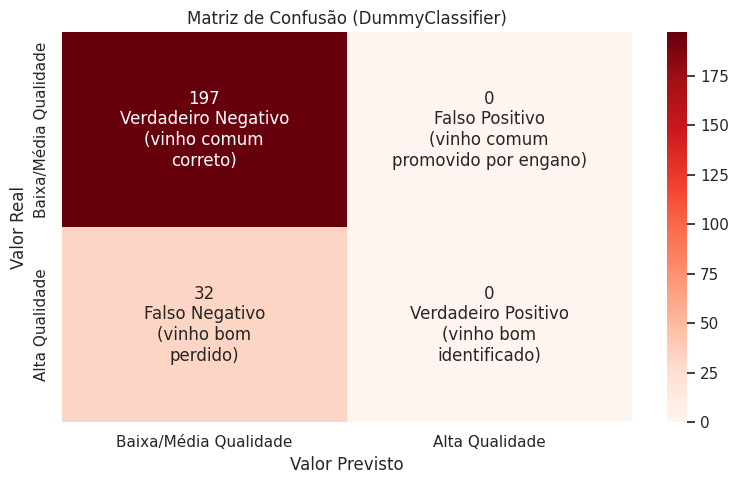

In [165]:
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy='prior')
dummy_classifier.fit(X_train, y_train)
dummy_predictions = dummy_classifier.predict(X_test)

dummy_accuracy = accuracy_score(y_test, dummy_predictions)
print(f"Acurácia Geral do Dummy Classifier: {dummy_accuracy:.2%}\n")

print("Relatório de Classificação do Dummy Classifier:")
print(classification_report(y_test, dummy_predictions, target_names=['Classe 0', 'Classe 1']))

dummy_confusion_matrix = confusion_matrix(y_test, dummy_predictions)

plotar_matriz_confusao(dummy_confusion_matrix, 'Matriz de Confusão (DummyClassifier)')

### KNN

Acurácia Geral do Modelo (KNN Padrão): 87.34%

Relatório de Classificação Completo (KNN Padrão):
              precision    recall  f1-score   support

    Classe 0       0.92      0.93      0.93       197
    Classe 1       0.55      0.53      0.54        32

    accuracy                           0.87       229
   macro avg       0.74      0.73      0.73       229
weighted avg       0.87      0.87      0.87       229



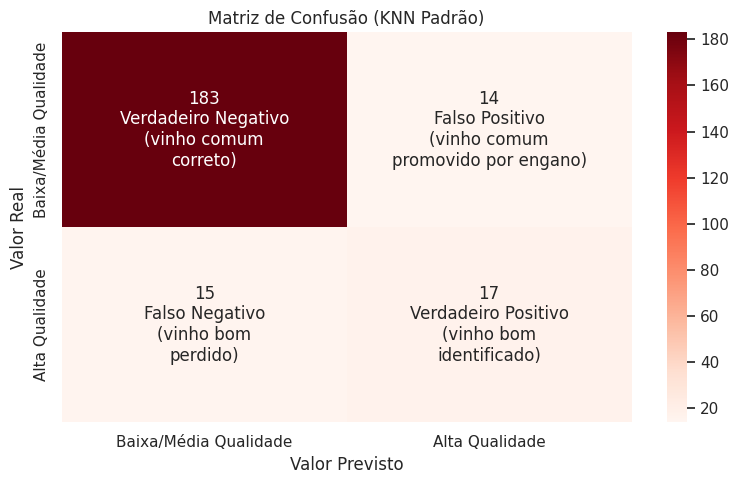

In [166]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

scaler_std = StandardScaler()
X_train_std_scaled = scaler_std.fit_transform(X_train)
X_test_std_scaled = scaler_std.transform(X_test)

knn_std_classifier = KNeighborsClassifier(n_neighbors=5, weights='distance', p=1)
knn_std_classifier.fit(X_train_std_scaled, y_train)

knn_std_predictions = knn_std_classifier.predict(X_test_std_scaled)

acuracia_std = accuracy_score(y_test, knn_std_predictions)
print(f"Acurácia Geral do Modelo (KNN Padrão): {acuracia_std:.2%}\n")

print("Relatório de Classificação Completo (KNN Padrão):")
print(classification_report(y_test, knn_std_predictions, target_names=['Classe 0', 'Classe 1']))

matriz_confusao_std = confusion_matrix(y_test, knn_std_predictions)

plotar_matriz_confusao(matriz_confusao_std, 'Matriz de Confusão (KNN Padrão)')

### KNN Winsorizado por Percentil

In [167]:
# Cópias do split único para não alterar os dados dos demais experimentos
X_train_perc = X_train.copy()
X_test_perc = X_test.copy()

# Limites calculados no treino e aplicados em ambos os conjuntos
limites_perc = {}
for col in X_train_perc.columns:
    p5, p95 = np.percentile(X_train_perc[col], [5, 95])
    limites_perc[col] = (p5, p95)
    X_train_perc[col] = X_train_perc[col].clip(p5, p95)
    X_test_perc[col] = X_test_perc[col].clip(p5, p95)

scaler_perc = StandardScaler()
X_train_perc_scaled = scaler_perc.fit_transform(X_train_perc)
X_test_perc_scaled = scaler_perc.transform(X_test_perc)

knn_perc_classifier = KNeighborsClassifier(n_neighbors=5, weights='distance', p=1)
knn_perc_classifier.fit(X_train_perc_scaled, y_train)

knn_perc_predictions = knn_perc_classifier.predict(X_test_perc_scaled)

acuracia_perc = accuracy_score(y_test, knn_perc_predictions)
print(f"Acurácia Geral do Modelo (KNN Winsorizado por Percentil): {acuracia_perc:.2%}\n")

print("Relatório de Classificação Completo (KNN Winsorizado por Percentil):")
print(classification_report(y_test, knn_perc_predictions, target_names=['Classe 0', 'Classe 1']))

matriz_confusao_perc = confusion_matrix(y_test, knn_perc_predictions)

Acurácia Geral do Modelo (KNN Winsorizado por Percentil): 87.77%

Relatório de Classificação Completo (KNN Winsorizado por Percentil):
              precision    recall  f1-score   support

    Classe 0       0.93      0.93      0.93       197
    Classe 1       0.56      0.56      0.56        32

    accuracy                           0.88       229
   macro avg       0.75      0.75      0.75       229
weighted avg       0.88      0.88      0.88       229



### KNN Winsorizado por IQR

Acurácia Geral do Modelo (KNN Winsorizado por IQR): 88.65%

Relatório de Classificação Completo (KNN Winsorizado por IQR):
              precision    recall  f1-score   support

    Classe 0       0.93      0.93      0.93       197
    Classe 1       0.59      0.59      0.59        32

    accuracy                           0.89       229
   macro avg       0.76      0.76      0.76       229
weighted avg       0.89      0.89      0.89       229



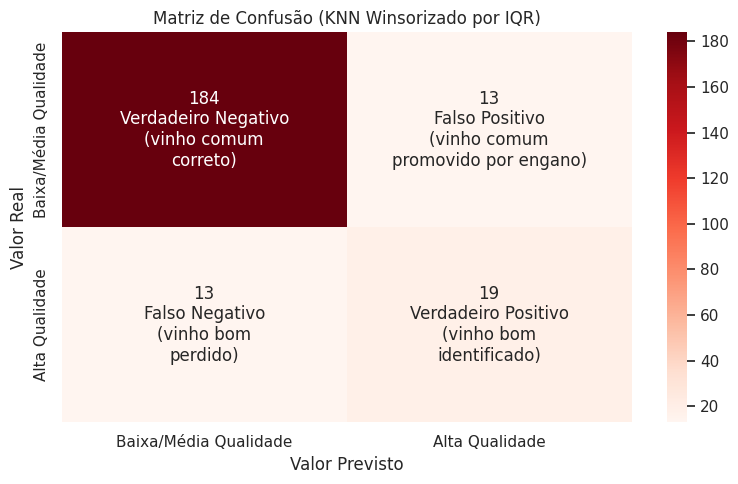

In [168]:
X_train_iqr = X_train.copy()
X_test_iqr = X_test.copy()

# Limites do bigode do boxplot calculados no treino e aplicados em ambos
limites_iqr = {}
for col in X_train_iqr.columns:
    Q1 = X_train_iqr[col].quantile(0.25)
    Q3 = X_train_iqr[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    limites_iqr[col] = (limite_inf, limite_sup)
    X_train_iqr[col] = X_train_iqr[col].clip(limite_inf, limite_sup)
    X_test_iqr[col] = X_test_iqr[col].clip(limite_inf, limite_sup)

scaler_iqr = StandardScaler()
X_train_iqr_scaled = scaler_iqr.fit_transform(X_train_iqr)
X_test_iqr_scaled = scaler_iqr.transform(X_test_iqr)

knn_iqr_classifier = KNeighborsClassifier(n_neighbors=5, weights='distance', p=1)
knn_iqr_classifier.fit(X_train_iqr_scaled, y_train)

knn_iqr_predictions = knn_iqr_classifier.predict(X_test_iqr_scaled)

acuracia_iqr = accuracy_score(y_test, knn_iqr_predictions)
print(f"Acurácia Geral do Modelo (KNN Winsorizado por IQR): {acuracia_iqr:.2%}\n")

print("Relatório de Classificação Completo (KNN Winsorizado por IQR):")
print(classification_report(y_test, knn_iqr_predictions, target_names=['Classe 0', 'Classe 1']))

matriz_confusao_iqr = confusion_matrix(y_test, knn_iqr_predictions)

plotar_matriz_confusao(matriz_confusao_iqr, 'Matriz de Confusão (KNN Winsorizado por IQR)')

### Validação Cruzada (K-Fold Estratificado)

In [169]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

# Pipeline garante que o scaler seja ajustado apenas no treino de cada fold
pipeline_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance', p=1))
])

cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=38)

# F1 como métrica por causa do desbalanceamento das classes
cv_scores = cross_val_score(pipeline_cv, X_train, y_train, cv=cv_splitter, scoring='f1')

print(f"F1 por fold: {cv_scores}")
print(f"F1 médio: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

F1 por fold: [0.59574468 0.41860465 0.70833333 0.6122449  0.54545455]
F1 médio: 0.576 (+/- 0.095)


### Grid Search — dados sem winsorização

Melhores parâmetros: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance', 'scaler': RobustScaler()}
Melhor F1 (validação cruzada): 0.613

Acurácia (teste): 88.65%
              precision    recall  f1-score   support

    Classe 0       0.93      0.94      0.93       197
    Classe 1       0.60      0.56      0.58        32

    accuracy                           0.89       229
   macro avg       0.76      0.75      0.76       229
weighted avg       0.88      0.89      0.88       229



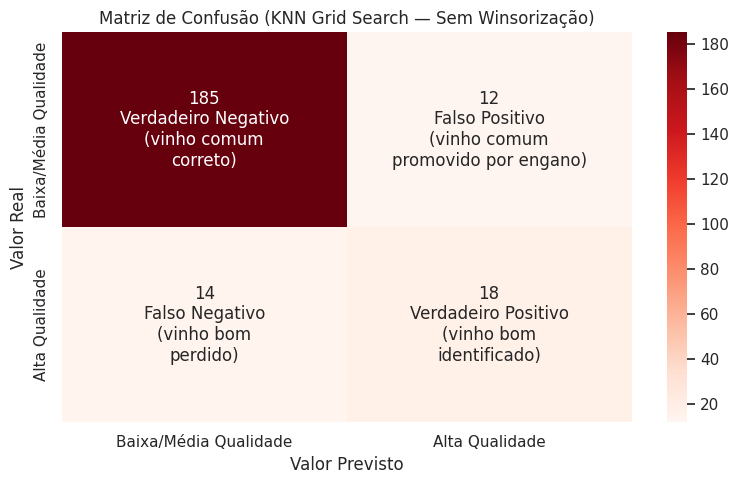

In [170]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'scaler': [MinMaxScaler(), StandardScaler(), RobustScaler()],
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

pipeline_gs = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])

gs_sem_winsor = GridSearchCV(pipeline_gs, param_grid, cv=cv_splitter, scoring='f1', n_jobs=-1)
gs_sem_winsor.fit(X_train, y_train)

print(f"Melhores parâmetros: {gs_sem_winsor.best_params_}")
print(f"Melhor F1 (validação cruzada): {gs_sem_winsor.best_score_:.3f}\n")

previsoes_gs = gs_sem_winsor.predict(X_test)

print(f"Acurácia (teste): {accuracy_score(y_test, previsoes_gs):.2%}")
print(classification_report(y_test, previsoes_gs, target_names=['Classe 0', 'Classe 1']))

matriz_confusao_gs = confusion_matrix(y_test, previsoes_gs)

plotar_matriz_confusao(matriz_confusao_gs,
                       'Matriz de Confusão (KNN Grid Search — Sem Winsorização)')

### Grid Search — winsorizado por percentil

Melhores parâmetros: {'knn__n_neighbors': 7, 'knn__p': 1, 'knn__weights': 'distance', 'scaler': MinMaxScaler()}
Melhor F1 (validação cruzada): 0.603

Acurácia (teste): 87.77%
              precision    recall  f1-score   support

    Classe 0       0.92      0.94      0.93       197
    Classe 1       0.57      0.50      0.53        32

    accuracy                           0.88       229
   macro avg       0.75      0.72      0.73       229
weighted avg       0.87      0.88      0.87       229



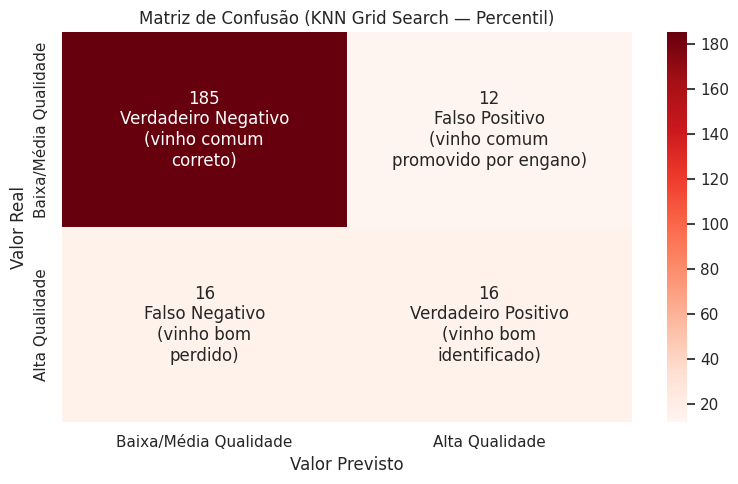

In [171]:
pipeline_gs_perc = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])

gs_perc = GridSearchCV(pipeline_gs_perc, param_grid, cv=cv_splitter, scoring='f1', n_jobs=-1)
gs_perc.fit(X_train_perc, y_train)

print(f"Melhores parâmetros: {gs_perc.best_params_}")
print(f"Melhor F1 (validação cruzada): {gs_perc.best_score_:.3f}\n")

previsoes_gs_perc = gs_perc.predict(X_test_perc)

print(f"Acurácia (teste): {accuracy_score(y_test, previsoes_gs_perc):.2%}")
print(classification_report(y_test, previsoes_gs_perc, target_names=['Classe 0', 'Classe 1']))

matriz_confusao_gs_perc = confusion_matrix(y_test, previsoes_gs_perc)

plotar_matriz_confusao(matriz_confusao_gs_perc,
                       'Matriz de Confusão (KNN Grid Search — Percentil)')

### Grid Search — winsorizado por IQR

Melhores parâmetros: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance', 'scaler': RobustScaler()}
Melhor F1 (validação cruzada): 0.620

Acurácia (teste): 88.65%
              precision    recall  f1-score   support

    Classe 0       0.94      0.93      0.93       197
    Classe 1       0.59      0.62      0.61        32

    accuracy                           0.89       229
   macro avg       0.76      0.78      0.77       229
weighted avg       0.89      0.89      0.89       229



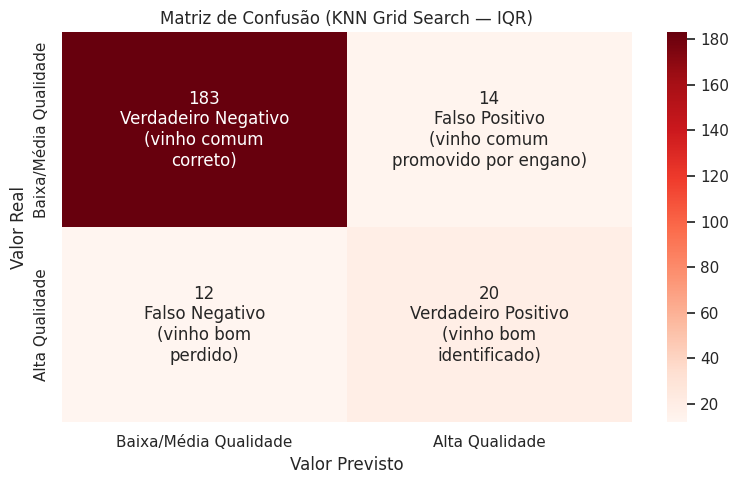

In [172]:
pipeline_gs_iqr = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier())
])

gs_iqr = GridSearchCV(pipeline_gs_iqr, param_grid, cv=cv_splitter, scoring='f1', n_jobs=-1)
gs_iqr.fit(X_train_iqr, y_train)

print(f"Melhores parâmetros: {gs_iqr.best_params_}")
print(f"Melhor F1 (validação cruzada): {gs_iqr.best_score_:.3f}\n")

previsoes_gs_iqr = gs_iqr.predict(X_test_iqr)

print(f"Acurácia (teste): {accuracy_score(y_test, previsoes_gs_iqr):.2%}")
print(classification_report(y_test, previsoes_gs_iqr, target_names=['Classe 0', 'Classe 1']))

matriz_confusao_gs_iqr = confusion_matrix(y_test, previsoes_gs_iqr)

plotar_matriz_confusao(matriz_confusao_gs_iqr,
                       'Matriz de Confusão (KNN Grid Search — IQR)')

### Interpretação de Modelo

/tmp/ipykernel_860/902549923.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancia, x='Importância', y='Variável', palette='Reds_r')


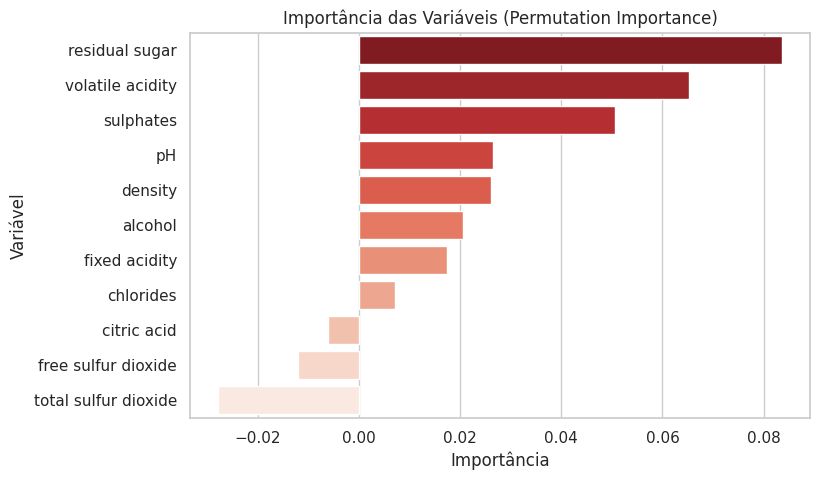

In [173]:
from sklearn.inspection import permutation_importance

result = permutation_importance(gs_iqr, X_test_iqr, y_test,
                                scoring='f1', n_repeats=10, random_state=38)

importancia = pd.DataFrame({
    'Variável': X.columns,
    'Importância': result.importances_mean
}).sort_values('Importância', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importancia, x='Importância', y='Variável', palette='Reds_r')
plt.title('Importância das Variáveis (Permutation Importance)')
plt.show()

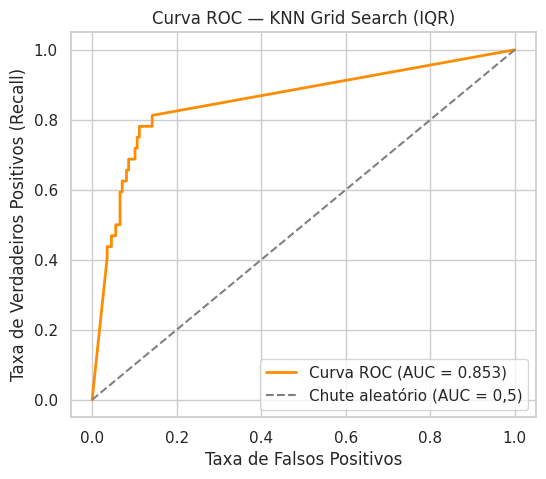

,Threshold,Acurácia (CV),Precision Classe 1 (CV),Recall Classe 1 (CV),F1 Classe 1 (CV)
0,0.30,0.851,0.478,0.772,0.590
1,0.35,0.887,0.582,0.669,0.623
2,0.40,0.898,0.633,0.638,0.635
3,0.45,0.899,0.645,0.614,0.629
4,0.50,0.899,0.647,0.606,0.626
5,0.60,0.903,0.664,0.606,0.634
6,0.70,0.891,0.721,0.346,0.468


In [174]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import cross_val_predict

# Curva ROC no teste (apenas visualização da capacidade de ranking do modelo)
probs = gs_iqr.predict_proba(X_test_iqr)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Chute aleatório (AUC = 0,5)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC — KNN Grid Search (IQR)')
plt.legend(loc='lower right')
plt.show()

# --- Escolha do threshold SEM vazamento ---
# cross_val_predict gera probabilidades out-of-fold no TREINO:
# cada amostra é prevista por um modelo que nunca a viu no fit.
from sklearn.metrics import precision_score, recall_score

probs_cv = cross_val_predict(gs_iqr.best_estimator_, X_train_iqr, y_train,
                             cv=cv_splitter, method='predict_proba')[:, 1]

linhas = []
for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70]:
    preds = (probs_cv >= threshold).astype(int)
    linhas.append({
        'Threshold': threshold,
        'Acurácia (CV)': accuracy_score(y_train, preds),
        'Precision Classe 1 (CV)': precision_score(y_train, preds),
        'Recall Classe 1 (CV)': recall_score(y_train, preds),
        'F1 Classe 1 (CV)': f1_score(y_train, preds)
    })

tabela_threshold = pd.DataFrame(linhas).round(3)
tabela_threshold

### Tabela Comparativa

Threshold escolhido via CV: 0.4
Acurácia do Modelo Final (threshold = 0.4): 88.21%

Relatório de Classificação do Modelo Final:
              precision    recall  f1-score   support

    Classe 0       0.94      0.92      0.93       197
    Classe 1       0.57      0.62      0.60        32

    accuracy                           0.88       229
   macro avg       0.75      0.77      0.76       229
weighted avg       0.89      0.88      0.88       229



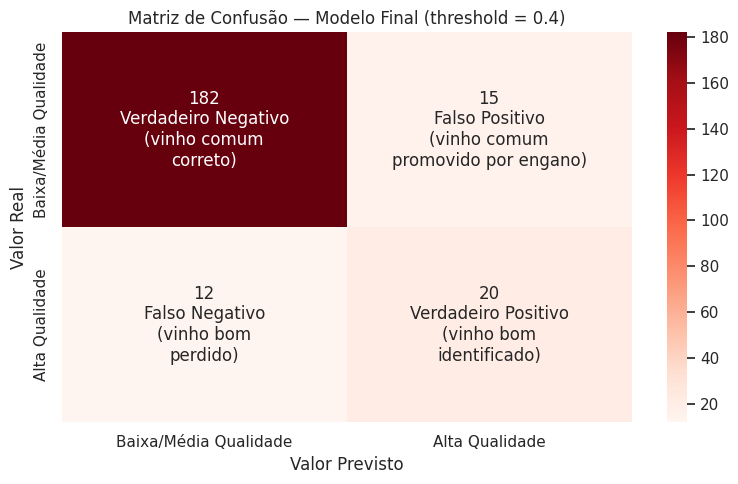

In [175]:
# Threshold escolhido pela análise de sensibilidade NA VALIDAÇÃO CRUZADA (treino),
# maximizando o F1 da Classe 1 — sem olhar o teste
threshold_final = tabela_threshold.loc[tabela_threshold['F1 Classe 1 (CV)'].idxmax(), 'Threshold']
print(f"Threshold escolhido via CV: {threshold_final}")

probs_final = gs_iqr.predict_proba(X_test_iqr)[:, 1]
previsoes_final = (probs_final >= threshold_final).astype(int)

acuracia_final = accuracy_score(y_test, previsoes_final)
print(f"Acurácia do Modelo Final (threshold = {threshold_final}): {acuracia_final:.2%}\n")

print("Relatório de Classificação do Modelo Final:")
print(classification_report(y_test, previsoes_final, target_names=['Classe 0', 'Classe 1']))

matriz_confusao_final = confusion_matrix(y_test, previsoes_final)

plotar_matriz_confusao(matriz_confusao_final,
                       f'Matriz de Confusão — Modelo Final (threshold = {threshold_final})')

In [176]:
resultados = pd.DataFrame([
    {'Modelo': 'Dummy (baseline)', 'Acurácia': accuracy_score(y_test, dummy_predictions), 'F1 Classe 1': f1_score(y_test, dummy_predictions)},
    {'Modelo': 'KNN padrão', 'Acurácia': accuracy_score(y_test, knn_std_predictions), 'F1 Classe 1': f1_score(y_test, knn_std_predictions)},
    {'Modelo': 'KNN winsorizado (percentil)', 'Acurácia': accuracy_score(y_test, knn_perc_predictions), 'F1 Classe 1': f1_score(y_test, knn_perc_predictions)},
    {'Modelo': 'KNN winsorizado (IQR)', 'Acurácia': accuracy_score(y_test, knn_iqr_predictions), 'F1 Classe 1': f1_score(y_test, knn_iqr_predictions)},
    {'Modelo': 'KNN Grid Search (sem winsorização)', 'Acurácia': accuracy_score(y_test, previsoes_gs), 'F1 Classe 1': f1_score(y_test, previsoes_gs)},
    {'Modelo': 'KNN Grid Search (percentil)', 'Acurácia': accuracy_score(y_test, previsoes_gs_perc), 'F1 Classe 1': f1_score(y_test, previsoes_gs_perc)},
    {'Modelo': 'KNN Grid Search (IQR)', 'Acurácia': accuracy_score(y_test, previsoes_gs_iqr), 'F1 Classe 1': f1_score(y_test, previsoes_gs_iqr)},
    {'Modelo': f'KNN Grid Search (IQR, threshold={threshold_final})', 'Acurácia': acuracia_final, 'F1 Classe 1': f1_score(y_test, previsoes_final)},
]).round(4)

resultados.sort_values('F1 Classe 1', ascending=False).reset_index(drop=True)

,Modelo,Acurácia,F1 Classe 1
0,KNN Grid Search (IQR),0.8865,0.6061
1,"KNN Grid Search (IQR, threshold=0.4)",0.8821,0.5970
2,KNN winsorizado (IQR),0.8865,0.5938
3,KNN Grid Search (sem winsorização),0.8865,0.5806
4,KNN winsorizado (percentil),0.8777,0.5625
5,KNN padrão,0.8734,0.5397
6,KNN Grid Search (percentil),0.8777,0.5333
7,Dummy (baseline),0.8603,0.0000


## 4.2 Modelo XGBoost

Divisão da base: Estamos utilizando 80% da base para treino e 20.

Obs.: O parâmetro stratify=y garante que a proporção de vinhos de alta e baixa qualidade seja mantida idêntica nos conjuntos de treino e de teste, evitando que o modelo aprenda de forma desbalanceada.

Deixar dentro do X apenas as variáveis preditoras (as características físico-químicas do vinho), removendo as "respostas" (quality e qualityBinary) e informações que não ajudam na previsão matemática (Id).

O XGBoost possui uma interface muito intuitiva e compatível com o padrão do Scikit-Learn, o que torna o treinamento bastante direto com o método .fit()

In [177]:
X = df.drop(columns=['quality', 'qualityBinary'])
y = df['qualityBinary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=38, stratify=y)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 914 amostras | Teste: 229 amostras


### Baseline de referência DummyClassifier

In [178]:
baseline = DummyClassifier(strategy='most_frequent', random_state=38)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print("Baseline (classe majoritária):")
print(f"  Acurácia: {accuracy_score(y_test, y_pred_base):.3f}")
print(f"  F1 (classe 1): {classification_report(y_test, y_pred_base, output_dict=True)['1']['f1-score']:.3f}")

Baseline (classe majoritária):
  Acurácia: 0.860
  F1 (classe 1): 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Validação cruzada (K-Fold estratificado)

In [179]:
# Peso para a classe minoritária
peso_balanceamento = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {peso_balanceamento:.2f}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=38)

xgb_default = xgb.XGBClassifier(
    objective='binary:logistic', eval_metric='logloss',
    scale_pos_weight=peso_balanceamento, random_state=38)

f1_default = cross_val_score(xgb_default, X_train, y_train, cv=cv, scoring='f1')
print(f"\nXGBoost default — F1 (CV 5-fold): {f1_default.mean():.3f} ± {f1_default.std():.3f}")

scale_pos_weight: 6.20

XGBoost default — F1 (CV 5-fold): 0.626 ± 0.123


### Grid Search

In [180]:
param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

grid = GridSearchCV(
    xgb.XGBClassifier(
        objective='binary:logistic', eval_metric='logloss',
        scale_pos_weight=peso_balanceamento, random_state=38),
    param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print(f"\nMelhores hiperparâmetros: {grid.best_params_}")
print(f"Melhor F1 médio (CV): {grid.best_score_:.3f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Melhores hiperparâmetros: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}
Melhor F1 médio (CV): 0.634


### Avaliação final no conjunto de teste

In [181]:
best = grid.best_estimator_
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

print("Relatório de Classificação (modelo otimizado):")
print(classification_report(y_test, y_pred, target_names=['Baixa/Média', 'Alta']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_proba):.3f}")

Relatório de Classificação (modelo otimizado):
              precision    recall  f1-score   support

 Baixa/Média       0.94      0.92      0.93       197
        Alta       0.57      0.62      0.60        32

    accuracy                           0.88       229
   macro avg       0.75      0.77      0.76       229
weighted avg       0.89      0.88      0.88       229

ROC-AUC: 0.911
PR-AUC:  0.691


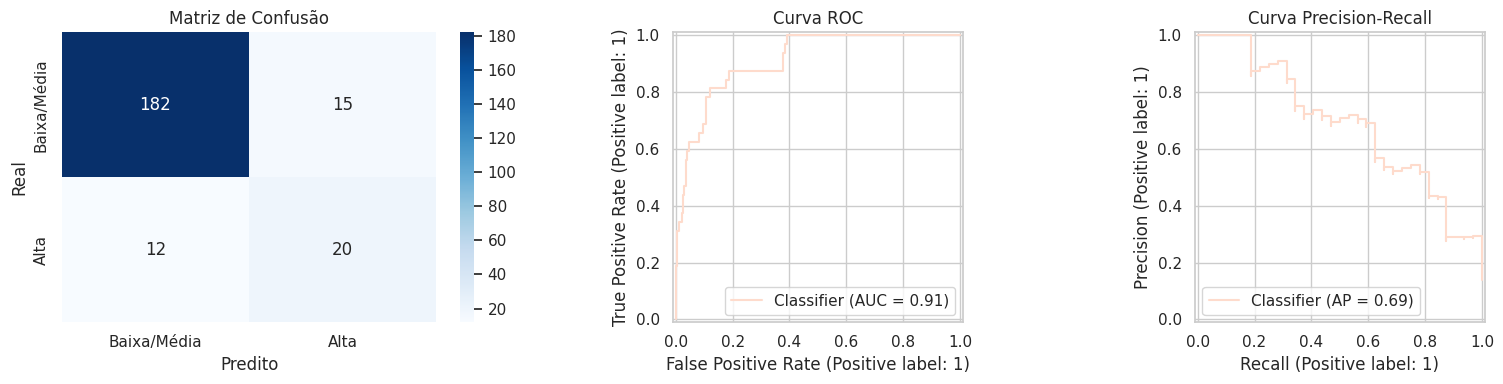

In [182]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Baixa/Média', 'Alta'],
            yticklabels=['Baixa/Média', 'Alta'])
axes[0].set_title('Matriz de Confusão')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Curva ROC')

# Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2])
axes[2].set_title('Curva Precision-Recall')

plt.tight_layout()
plt.show()

### Análise de resultados modelo XGBoost
Verdadeiros Positivos (Canto inferior direito): O vinho era de Alta qualidade e o modelo acertou.

Verdadeiro Negativo (Canto superior esquerdo): O vinho era comum e o modelo cravou corretamente.

Falsos Negativos (Canto inferior esquerdo): O vinho era excelente, mas o modelo deixou passar e rebaixou para Baixa/Média.

Falso Positivo (Canto superior direito): O modelo disse que o vinho era de Alta qualidade, mas na verdade não era.

A Acurácia geral ficou em 0.90 (90%).

### Importância das variáveis

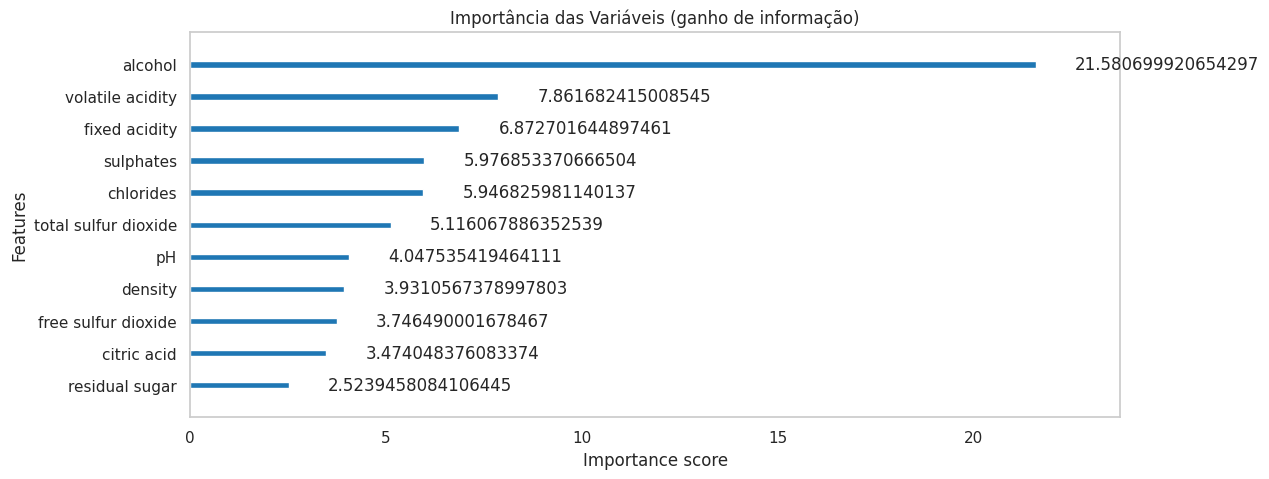

In [183]:
plt.rcParams["figure.figsize"] = (12, 5)
xgb.plot_importance(best, importance_type='gain',
                    title='Importância das Variáveis (ganho de informação)',
                    grid=False, color='#1f77b4')
plt.show()

### Analise das principais caracteristicas para um bom vinho
Alcohol - Score 10.49: O teor alcoólico é, de longe, o fator decisivo para o modelo. Na maioria das vezes que o modelo acertou um vinho de alta qualidade, a regra matemática de separação passava pelo nível de álcool.

Sulphates e citric acid: Com pontuações na casa de 4.0 a 4.5, os sulfatos (que ajudam na preservação e muitas vezes indicam práticas de vinificação específicas) e o ácido cítrico (que traz frescor) são os próximos na hierarquia de decisão.

Volatile acidity - Score 2.60: A acidez volátil é crucial porque, em níveis altos, ela dá ao vinho um cheiro e gosto de vinagre. O modelo provavelmente aprendeu a usar essa variável para "rebaixar" a nota de vinhos que teriam potencial, mas apresentam esse defeito.

Fatores como cloretos (chlorides, que medem o sal no vinho) trouxeram menos de 1 ponto de ganho de informação. Isso significa que, na prática, variar a quantidade de sal muda muito pouco a probabilidade de o vinho ser classificado como "Alta qualidade" pelo algoritmo.

### Simulação com um novo vinho

In [184]:
novo_vinho = pd.DataFrame({
    'fixed acidity': [7.4],
    'volatile acidity': [0.30],
    'citric acid': [0.40],
    'residual sugar': [2.0],
    'chlorides': [0.07],
    'free sulfur dioxide': [15.0],
    'total sulfur dioxide': [45.0],
    'density': [0.995],
    'pH': [3.30],
    'sulphates': [0.80],
    'alcohol': [12.5],
    'Id': [0] # Adicionando um Id de placeholder para corresponder ao modelo treinado
})
# Alinhando as colunas de novo_vinho com as colunas de X_train
novo_vinho = novo_vinho[X_train.columns]

previsao = best.predict(novo_vinho)
prob = best.predict_proba(novo_vinho)[0][1] * 100

print("--- Resultado da Análise do Novo Vinho ---")
print("Veredito: Vinho de ALTA Qualidade!" if previsao[0] == 1
      else "Veredito: Vinho de Baixa/Média Qualidade.")
print(f"Confiança do modelo: {prob:.1f}%")

--- Resultado da Análise do Novo Vinho ---
Veredito: Vinho de ALTA Qualidade!
Confiança do modelo: 93.3%


## 4.3 Modelo Random Forest

In [185]:
X = df.drop(columns=['quality', 'qualityBinary'])
y = df['qualityBinary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=38, stratify=y)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 914 amostras | Teste: 229 amostras


### Baseline de referência

In [186]:
baseline = DummyClassifier(strategy='most_frequent', random_state=38)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

print("Baseline (classe majoritária):")
print(f"  Acurácia: {accuracy_score(y_test, y_pred_base):.3f}")
print(f"  F1 (classe 1): {classification_report(y_test, y_pred_base, output_dict=True)['1']['f1-score']:.3f}")

Baseline (classe majoritária):
  Acurácia: 0.860
  F1 (classe 1): 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Validação cruzada (K-Fold estratificado)

In [187]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=38)

rf_default = RandomForestClassifier(
    n_estimators=100, random_state=38, class_weight='balanced')

f1_default = cross_val_score(rf_default, X_train, y_train, cv=cv, scoring='f1')
print(f"Random Forest default — F1 (CV 5-fold): {f1_default.mean():.3f} ± {f1_default.std():.3f}")

Random Forest default — F1 (CV 5-fold): 0.600 ± 0.040


### Grid Search

In [188]:
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2'],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=38, class_weight='balanced'),
    param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print(f"\nMelhores hiperparâmetros: {grid.best_params_}")
print(f"Melhor F1 médio (CV): {grid.best_score_:.3f}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

Melhores hiperparâmetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Melhor F1 médio (CV): 0.649


### Avaliação final no conjunto de teste

In [189]:
best = grid.best_estimator_
y_pred = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:, 1]

print("Relatório de Classificação (modelo otimizado):")
print(classification_report(y_test, y_pred, target_names=['Baixa/Média', 'Alta']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC:  {average_precision_score(y_test, y_proba):.3f}")

Relatório de Classificação (modelo otimizado):
              precision    recall  f1-score   support

 Baixa/Média       0.93      0.95      0.94       197
        Alta       0.63      0.53      0.58        32

    accuracy                           0.89       229
   macro avg       0.78      0.74      0.76       229
weighted avg       0.88      0.89      0.89       229

ROC-AUC: 0.922
PR-AUC:  0.694


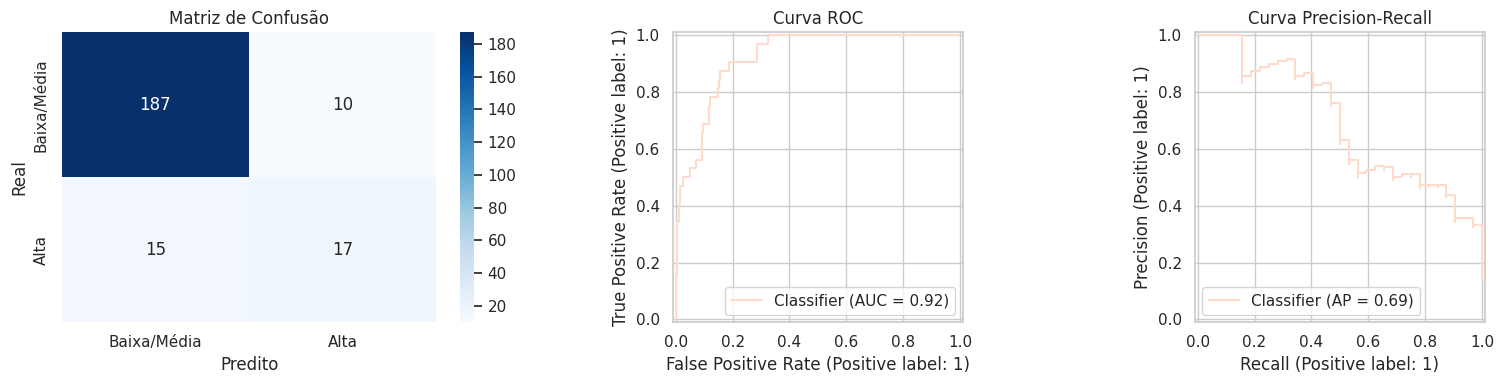

In [190]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Baixa/Média', 'Alta'],
            yticklabels=['Baixa/Média', 'Alta'])
axes[0].set_title('Matriz de Confusão')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predito')

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Curva ROC')

# Curva Precision-Recall
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2])
axes[2].set_title('Curva Precision-Recall')

plt.tight_layout()
plt.show()

### Importância das variáveis

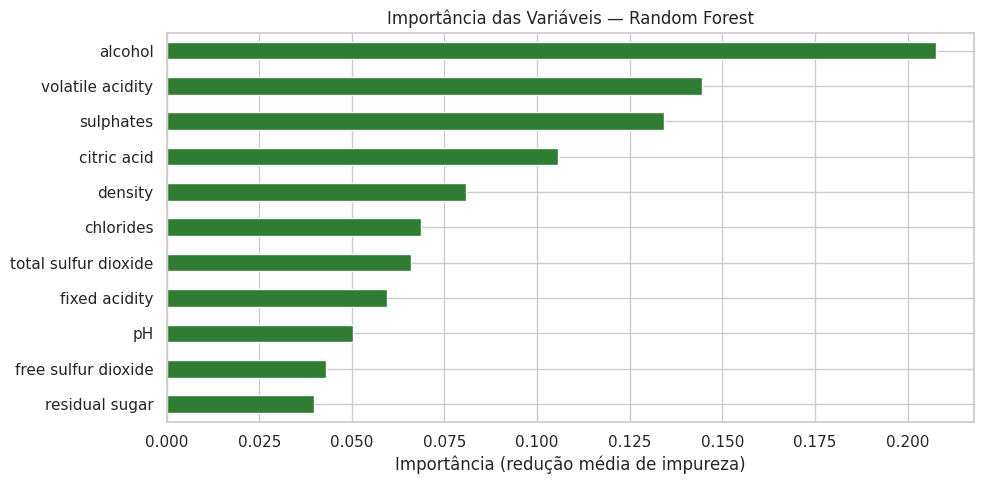

In [191]:
importancias = pd.Series(best.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10, 5))
importancias.plot.barh(color='#2e7d32')
plt.title('Importância das Variáveis — Random Forest')
plt.xlabel('Importância (redução média de impureza)')
plt.tight_layout()
plt.show()